<a href="https://colab.research.google.com/github/RohitDeorukhkar/Telecom-Churn-Analysis/blob/main/Glassdore_Job_Salary_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name - Glassdore Job Salary prediction**

##### **Project Type**    - EDA/Regression
##### **Contribution**    - Individual

# **Problem Statement**

How does salary vary by job position (e.g., Data Scientist vs. Software Engineer vs. DevOps Engineer)?


How does salary vary by job Experaince? (e.g., Data Scientist vs. Software Engineer vs. DevOps Engineer)?

what is the count of Jobs per position by location?

How do salaries differ by location (e.g., San Francisco vs. Austin vs. New York)?

Can we build a predictive model to estimate salaries based on job attributes?

By analyzing this dataset, we can predict salary ranges, uncover market trends, and provide insights to tech professionals and organizations.

# **Project Summary -**

**Salary-Predictions:**

Created a tool that estimates data science salaries using the data from the Glass Door website.
From glassdoor dataset using python and selenium
Engineered features from the text of each job description to quantify the value companies put on python, excel, aws, and spark.
Optimized Linear, Lasso, and Random Forest Regressors using GridsearchCV to reach the best model.

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# **1. Know Your Data**

In [ ]:
# Load Dataset
filepath='/content/drive/MyDrive/Data set/Salary data.csv'
df=pd.read_csv(filepath)

In [ ]:
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),-1
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,Security Services,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),"Oak Ridge National Laboratory, National Renewa..."
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


In [ ]:
df.shape

(956, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 956 entries, 0 to 955
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         956 non-null    int64  
 1   Job Title          956 non-null    object 
 2   Salary Estimate    956 non-null    object 
 3   Job Description    956 non-null    object 
 4   Rating             956 non-null    float64
 5   Company Name       956 non-null    object 
 6   Location           956 non-null    object 
 7   Headquarters       956 non-null    object 
 8   Size               956 non-null    object 
 9   Founded            956 non-null    int64  
 10  Type of ownership  956 non-null    object 
 11  Industry           956 non-null    object 
 12  Sector             956 non-null    object 
 13  Revenue            956 non-null    object 
 14  Competitors        956 non-null    object 
dtypes: float64(1), int64(2), object(12)
memory usage: 112.2+ KB


In [ ]:
# Dataset Duplicate Value Count
len(df[df.duplicated()])

0

In [ ]:
# Missing Values/Null Values
df.isnull().sum()

,0
Unnamed: 0,0
Job Title,0
Salary Estimate,0
Job Description,0
Rating,0
Company Name,0
Location,0
Headquarters,0
Size,0
Founded,0


**What we get form dataset?**

This data has no missing or duplicated value. It has 956 rows & 15 columns

# **2. Understanding Your Variables**

In [ ]:
# Dataset Columns
df.columns

Index(['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description',
       'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors'],
      dtype='object')

In [ ]:
# Dataset Describe
df.describe(include='all')

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
count,956.000000,956,956,956,956.000000,956,956,956,956,956.000000,956,956,956,956,956
unique,NaN,328,417,596,NaN,448,237,235,9,NaN,13,63,25,14,149
top,NaN,Data Scientist,-1,Data Engineer with R\n\n-Contract Role in Atla...,NaN,Takeda Pharmaceuticals\n3.7,"New York, NY","New York, NY",1001 to 5000 employees,NaN,Company - Private,Biotech & Pharmaceuticals,Information Technology,Unknown / Non-Applicable,-1
freq,NaN,178,214,4,NaN,14,78,75,177,NaN,532,148,239,299,634
mean,477.500000,NaN,NaN,NaN,3.601255,NaN,NaN,NaN,NaN,1774.605649,NaN,NaN,NaN,NaN,NaN
std,276.117729,NaN,NaN,NaN,1.067619,NaN,NaN,NaN,NaN,598.942517,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,-1.000000,NaN,NaN,NaN,NaN,NaN
25%,238.750000,NaN,NaN,NaN,3.300000,NaN,NaN,NaN,NaN,1937.000000,NaN,NaN,NaN,NaN,NaN
50%,477.500000,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,1992.000000,NaN,NaN,NaN,NaN,NaN
75%,716.250000,NaN,NaN,NaN,4.200000,NaN,NaN,NaN,NaN,2008.000000,NaN,NaN,NaN,NaN,NaN


# **3. Data Wrangling**

In [ ]:
#To check if salary data provided by Per hour, by employer (1 : provided, 0: not provided) or glassdore estimated
df['hourly'] = df['Salary Estimate'].apply(lambda x: 1 if 'per hour' in x.lower() else 0)
df['employer_provided'] = df['Salary Estimate'].apply(lambda x: 1 if 'employer provided salary:' in x.lower() else 0)
df['Glassdoor est'] = df['Salary Estimate'].apply(lambda x: 1 if 'glassdoor est.' in x.lower() else 0)

df['hourly'].value_counts(),df['employer_provided'].value_counts(),df['Glassdoor est'].value_counts()

(hourly
 0    932
 1     24
 Name: count, dtype: int64,
 employer_provided
 0    939
 1     17
 Name: count, dtype: int64,
 Glassdoor est
 1    713
 0    243
 Name: count, dtype: int64)

In [ ]:
# data cleaning (to remove -1 & replaces symbols)
df = df[df['Salary Estimate'] != '-1']
salary = df['Salary Estimate'].apply(lambda x: x.split('(')[0])
minus_Kd = salary.apply(lambda x: x.replace('K','').replace('$',''))


In [ ]:
#remove unneccsary text
min_hr = minus_Kd.apply(lambda x: x.lower().replace('per hour','').replace('employer provided salary:',''))

In [ ]:
min_hr

,Salary Estimate
0,53-91
1,63-112
2,80-90
3,56-97
4,86-143
...,...
950,58-111
951,72-133
952,56-91
953,95-160


In [ ]:
# Create Min,Max & Avg salary
df['min_salary'] = min_hr.apply(lambda x: int(x.split('-')[0]))
df['max_salary'] = min_hr.apply(lambda x: int(x.split('-')[1]))
df['avg_salary'] = (df.min_salary+df.max_salary)/2
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,Industry,Sector,Revenue,Competitors,hourly,employer_provided,Glassdoor est,min_salary,max_salary,avg_salary
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,...,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),-1,0,0,1,53,91,72.0
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,...,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,0,0,1,63,112,87.5
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,...,Security Services,Business Services,$100 to $500 million (USD),-1,0,0,1,80,90,85.0
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,...,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),"Oak Ridge National Laboratory, National Renewa...",0,0,1,56,97,76.5
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,...,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",0,0,1,86,143,114.5


In [ ]:
# Separates rating from name
df['company_txt'] = df.apply(lambda x: x['Company Name'] if x['Rating'] <0 else x['Company Name'][:-3], axis = 1)
df

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,Sector,Revenue,Competitors,hourly,employer_provided,Glassdoor est,min_salary,max_salary,avg_salary,company_txt
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,...,Aerospace & Defense,$50 to $100 million (USD),-1,0,0,1,53,91,72.0,Tecolote Research\n
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,...,Health Care,$2 to $5 billion (USD),-1,0,0,1,63,112,87.5,University of Maryland Medical System\n
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,...,Business Services,$100 to $500 million (USD),-1,0,0,1,80,90,85.0,KnowBe4\n
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,...,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),"Oak Ridge National Laboratory, National Renewa...",0,0,1,56,97,76.5,PNNL\n
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,...,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",0,0,1,86,143,114.5,Affinity Solutions\n
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950,950,"Sr Scientist, Immuno-Oncology - Oncology",$58K-$111K (Glassdoor est.),Site Name: USA - Massachusetts - Cambridge\nPo...,3.9,GSK\n3.9,"Cambridge, MA","Brentford, United Kingdom",10000+ employees,1830,...,Biotech & Pharmaceuticals,$10+ billion (USD),"Pfizer, AstraZeneca, Merck",0,0,1,58,111,84.5,GSK\n
951,951,Senior Data Engineer,$72K-$133K (Glassdoor est.),THE CHALLENGE\nEventbrite has a world-class da...,4.4,Eventbrite\n4.4,"Nashville, TN","San Francisco, CA",1001 to 5000 employees,2006,...,Information Technology,$100 to $500 million (USD),"See Tickets, TicketWeb, Vendini",0,0,1,72,133,102.5,Eventbrite\n
952,952,"Project Scientist - Auton Lab, Robotics Institute",$56K-$91K (Glassdoor est.),The Auton Lab at Carnegie Mellon University is...,2.6,Software Engineering Institute\n2.6,"Pittsburgh, PA","Pittsburgh, PA",501 to 1000 employees,1984,...,Education,Unknown / Non-Applicable,-1,0,0,1,56,91,73.5,Software Engineering Institute\n
953,953,Data Science Manager,$95K-$160K (Glassdoor est.),Data Science ManagerResponsibilities:\n\nOvers...,3.2,"Numeric, LLC\n3.2","Allentown, PA","Chadds Ford, PA",1 to 50 employees,-1,...,Business Services,$5 to $10 million (USD),-1,0,0,1,95,160,127.5,"Numeric, LLC\n"


In [ ]:
#count jobs per location or state
df['job_state'] = df['Location'].apply(lambda x: x.split(',')[1])
df.job_state.value_counts()

,count
job_state,
CA,151
MA,103
NY,72
VA,41
IL,40
MD,35
PA,33
TX,28
WA,21


In [ ]:
# whether job location & company state is same?
df['same_state'] = df.apply(lambda x: 1 if x.Location == x.Headquarters else 0, axis = 1)
df['same_state'].value_counts()

,count
same_state,
1,414
0,328


In [ ]:
# age of the comoany
df['age'] = df.Founded.apply(lambda x: x if x <1 else 2020 - x)
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,hourly,employer_provided,Glassdoor est,min_salary,max_salary,avg_salary,company_txt,job_state,same_state,age
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,...,0,0,1,53,91,72.0,Tecolote Research\n,NM,0,47
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,...,0,0,1,63,112,87.5,University of Maryland Medical System\n,MD,0,36
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,...,0,0,1,80,90,85.0,KnowBe4\n,FL,1,10
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,...,0,0,1,56,97,76.5,PNNL\n,WA,1,55
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,...,0,0,1,86,143,114.5,Affinity Solutions\n,NY,1,22


In [ ]:
# create column to indicate which job require Python langaue
df['python_yn'] = df['Job Description'].apply(lambda x: 1 if 'python' in x.lower() else 0)
df.python_yn.value_counts()

,count
python_yn,
1,392
0,350


In [ ]:
# create column to indicate which job require R langaage
df['R_yn'] = df['Job Description'].apply(lambda x: 1 if 'r studio' in x.lower() or 'r-studio' in x.lower() else 0)
df.R_yn.value_counts()

,count
R_yn,
0,740
1,2


In [ ]:
# create column to indicate which job require spark
df['spark'] = df['Job Description'].apply(lambda x: 1 if 'spark' in x.lower() else 0)
df.spark.value_counts()

,count
spark,
0,575
1,167


In [ ]:
# create column to indicate which job require aws
df['aws'] = df['Job Description'].apply(lambda x: 1 if 'aws' in x.lower() else 0)
df.aws.value_counts()

,count
aws,
0,566
1,176


In [ ]:
# create column to indicate which job require excel
df['excel'] = df['Job Description'].apply(lambda x: 1 if 'excel' in x.lower() else 0)
df.excel.value_counts()

,count
excel,
1,388
0,354


In [ ]:
df.columns

Index(['Unnamed: 0', 'Job Title', 'Salary Estimate', 'Job Description',
       'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'employer_provided', 'Glassdoor est', 'min_salary',
       'max_salary', 'avg_salary', 'company_txt', 'job_state', 'same_state',
       'age', 'python_yn', 'R_yn', 'spark', 'aws', 'excel'],
      dtype='object')

In [ ]:
#To remove 'unnamed' column
df_out = df.drop(['Unnamed: 0'], axis =1)

In [ ]:
df_out

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,avg_salary,company_txt,job_state,same_state,age,python_yn,R_yn,spark,aws,excel
0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,...,72.0,Tecolote Research\n,NM,0,47,1,0,0,0,1
1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,...,87.5,University of Maryland Medical System\n,MD,0,36,1,0,0,0,0
2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,...,85.0,KnowBe4\n,FL,1,10,1,0,1,0,1
3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,...,76.5,PNNL\n,WA,1,55,1,0,0,0,0
4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,...,114.5,Affinity Solutions\n,NY,1,22,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950,"Sr Scientist, Immuno-Oncology - Oncology",$58K-$111K (Glassdoor est.),Site Name: USA - Massachusetts - Cambridge\nPo...,3.9,GSK\n3.9,"Cambridge, MA","Brentford, United Kingdom",10000+ employees,1830,Company - Public,...,84.5,GSK\n,MA,0,190,0,0,0,1,0
951,Senior Data Engineer,$72K-$133K (Glassdoor est.),THE CHALLENGE\nEventbrite has a world-class da...,4.4,Eventbrite\n4.4,"Nashville, TN","San Francisco, CA",1001 to 5000 employees,2006,Company - Public,...,102.5,Eventbrite\n,TN,0,14,1,0,1,1,0
952,"Project Scientist - Auton Lab, Robotics Institute",$56K-$91K (Glassdoor est.),The Auton Lab at Carnegie Mellon University is...,2.6,Software Engineering Institute\n2.6,"Pittsburgh, PA","Pittsburgh, PA",501 to 1000 employees,1984,College / University,...,73.5,Software Engineering Institute\n,PA,1,36,0,0,0,0,1
953,Data Science Manager,$95K-$160K (Glassdoor est.),Data Science ManagerResponsibilities:\n\nOvers...,3.2,"Numeric, LLC\n3.2","Allentown, PA","Chadds Ford, PA",1 to 50 employees,-1,Company - Private,...,127.5,"Numeric, LLC\n",PA,0,-1,0,0,0,0,1


In [ ]:
#create fucntion to formalize job title
def job_simple(title):
    if 'data scientist' in title.lower():
        return 'data scientist'
    elif 'data engineer' in title.lower():
        return 'data engineer'
    elif 'analyst' in title.lower():
        return 'analyst'
    elif 'machine learning' in title.lower():
        return 'mle'
    elif 'manager' in title.lower():
        return 'manager'
    elif 'director' in title.lower():
        return 'director'
    else:
        return 'na'

In [ ]:
#Craete function to decide seniority
def seniority(title):
    if 'sr' in title.lower() or 'senior' in title.lower() or 'sr' in title.lower() or 'lead' in title.lower() or 'principal' in title.lower():
        return 'senior'
    elif 'jr' in title.lower() or 'jr.' in title.lower():
        return 'jr'
    else:
        return 'na'

In [ ]:
df['job'] = df['Job Title'].apply(job_simple)
df['seniority'] = df['Job Title'].apply(seniority)

In [ ]:
df.job.value_counts()

,count
job,
data scientist,279
na,184
data engineer,119
analyst,102
manager,22
mle,22
director,14


In [ ]:
df.seniority.value_counts()

,count
seniority,
na,520
senior,220
jr,2


In [ ]:
# remove spaces & correct values of states
df['job_state']= df.job_state.apply(lambda x: x.strip() if x.strip().lower() != 'los angeles' else 'CA')
df.job_state.value_counts()

,count
job_state,
CA,152
MA,103
NY,72
VA,41
IL,40
MD,35
PA,33
TX,28
WA,21


In [ ]:
#calculate the length of each job description
df['desc_len'] = df['Job Description'].apply(lambda x: len(x))
df['desc_len']

,desc_len
0,2536
1,4783
2,3461
3,3883
4,2728
...,...
950,6162
951,6130
952,3078
953,1642


In [ ]:
#To find number of competitors
df['num_comp'] = df['Competitors'].apply(lambda x: len(x.split(',')) if x != '-1' else 0)
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,age,python_yn,R_yn,spark,aws,excel,job,seniority,desc_len,num_comp
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,...,47,1,0,0,0,1,data scientist,na,2536,0
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,...,36,1,0,0,0,0,data scientist,na,4783,0
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,...,10,1,0,1,0,1,data scientist,na,3461,0
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,...,55,1,0,0,0,0,data scientist,na,3883,3
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,...,22,1,0,0,0,1,data scientist,na,2728,3


In [ ]:
df['Competitors']

,Competitors
0,-1
1,-1
2,-1
3,"Oak Ridge National Laboratory, National Renewa..."
4,"Commerce Signals, Cardlytics, Yodlee"
...,...
950,"Pfizer, AstraZeneca, Merck"
951,"See Tickets, TicketWeb, Vendini"
952,-1
953,-1


In [ ]:
#To find Min & Max salary
df['min_salary'] = df.apply(lambda x: x.min_salary*2 if x.hourly ==1 else x.min_salary, axis =1)
df['max_salary'] = df.apply(lambda x: x.max_salary*2 if x.hourly ==1 else x.max_salary, axis =1)

In [ ]:
#To get min,max salary for available data
df[df.hourly ==1][['hourly','min_salary','max_salary']]

,hourly,min_salary,max_salary
197,1,34,48
209,1,42,68
240,1,36,50
247,1,42,68
257,1,30,50
307,1,34,48
337,1,42,68
427,1,36,50
437,1,48,78
456,1,42,68


In [ ]:
#To remove spaces in company name
df['company_txt'] = df.company_txt.apply(lambda x: x.replace('\n', ''))
df['company_txt']

,company_txt
0,Tecolote Research
1,University of Maryland Medical System
2,KnowBe4
3,PNNL
4,Affinity Solutions
...,...
950,GSK
951,Eventbrite
952,Software Engineering Institute
953,"Numeric, LLC"


In [ ]:
df.describe()

,Unnamed: 0,Rating,Founded,hourly,employer_provided,Glassdoor est,min_salary,max_salary,avg_salary,same_state,age,python_yn,R_yn,spark,aws,excel,desc_len,num_comp
count,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000
mean,469.129380,3.618868,1837.154987,0.032345,0.022911,0.960916,74.719677,128.149596,100.626011,0.557951,46.591644,0.528302,0.002695,0.225067,0.237197,0.522911,3869.545822,1.053908
std,279.793117,0.801210,497.183763,0.177034,0.149721,0.193925,30.980593,45.220324,38.855948,0.496965,53.778815,0.499535,0.051882,0.417908,0.425651,0.499812,1521.495868,1.384239
min,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,15.000000,16.000000,13.500000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,407.000000,0.000000
25%,221.500000,3.300000,1939.000000,0.000000,0.000000,1.000000,52.000000,96.000000,73.500000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2801.000000,0.000000
50%,472.500000,3.700000,1988.000000,0.000000,0.000000,1.000000,69.500000,124.000000,97.500000,1.000000,24.000000,1.000000,0.000000,0.000000,0.000000,1.000000,3731.000000,0.000000
75%,707.750000,4.000000,2007.000000,0.000000,0.000000,1.000000,91.000000,155.000000,122.500000,1.000000,59.000000,1.000000,0.000000,0.000000,0.000000,1.000000,4740.000000,3.000000
max,955.000000,5.000000,2019.000000,1.000000,1.000000,1.000000,202.000000,306.000000,254.000000,1.000000,276.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10051.000000,4.000000


# **4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables**

**Histogram**

<Axes: >

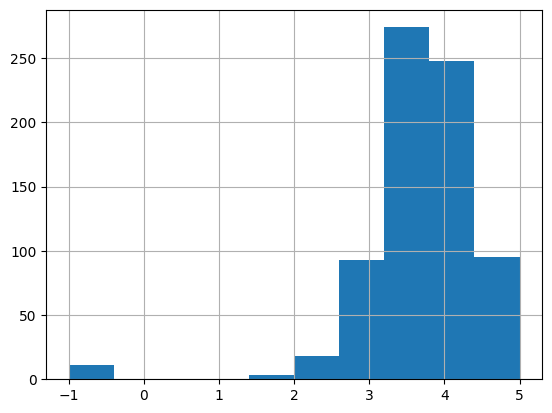

In [ ]:
df.Rating.hist()

<Axes: >

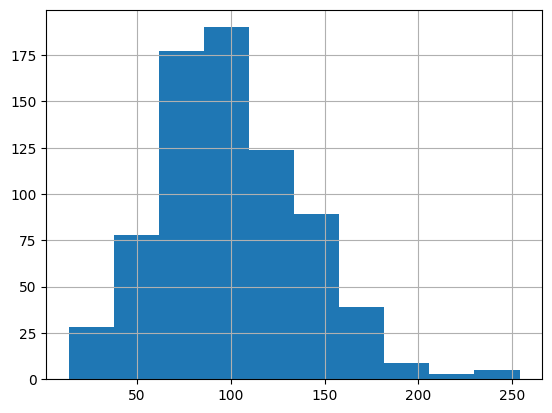

In [ ]:
df.avg_salary.hist()

<Axes: >

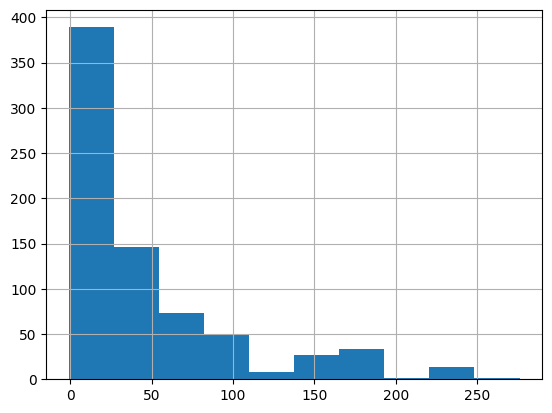

In [ ]:
df.age.hist()

<Axes: >

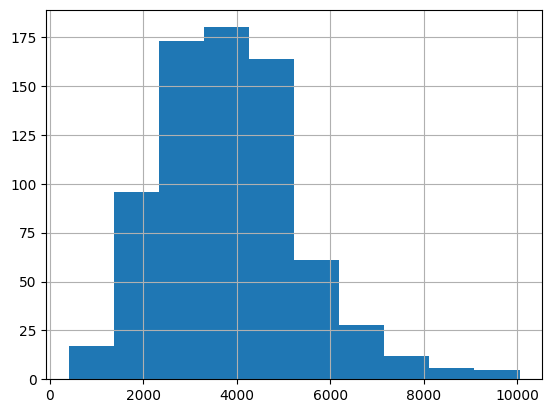

In [ ]:
df.desc_len.hist()

**Correlation**

In [ ]:
df[['age','avg_salary','Rating','desc_len']].corr()

,age,avg_salary,Rating,desc_len
age,1.000000,0.019655,0.021655,0.163911
avg_salary,0.019655,1.000000,0.013492,0.078808
Rating,0.021655,0.013492,1.000000,-0.012281
desc_len,0.163911,0.078808,-0.012281,1.000000


<Axes: >

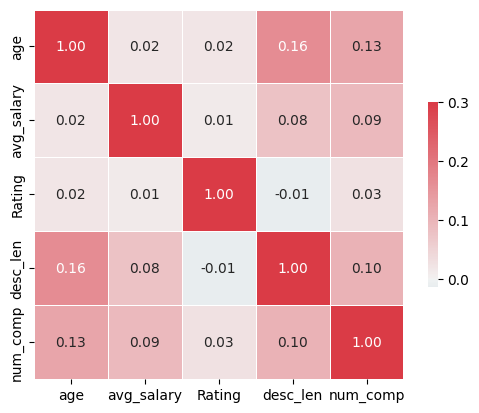

In [ ]:
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(df[['age','avg_salary','Rating','desc_len','num_comp']].corr(),vmax=.3, center=0, cmap=cmap,annot=True,fmt=".2f",
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

**Top 20 Frequency of jobs by categories (Location, Headquarters, and company_txt)in Bar graph**

In [ ]:
df_cat = df[['Location', 'Headquarters', 'Size','Type of ownership', 'Industry', 'Sector', 'Revenue', 'company_txt', 'job_state','same_state', 'python_yn', 'R_yn',
       'spark', 'aws', 'excel', 'job', 'seniority']]

graph for Location: total = 20


/tmp/ipykernel_1056/1701252395.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=cat_num.index, y=cat_num, palette="husl")
/tmp/ipykernel_1056/1701252395.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


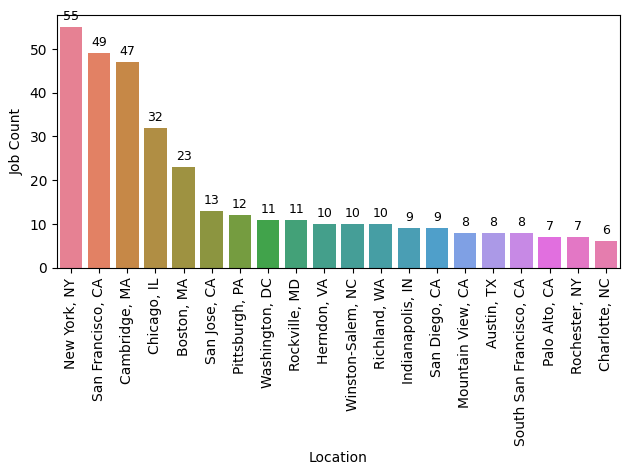

graph for Headquarters: total = 20


/tmp/ipykernel_1056/1701252395.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=cat_num.index, y=cat_num, palette="husl")
/tmp/ipykernel_1056/1701252395.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


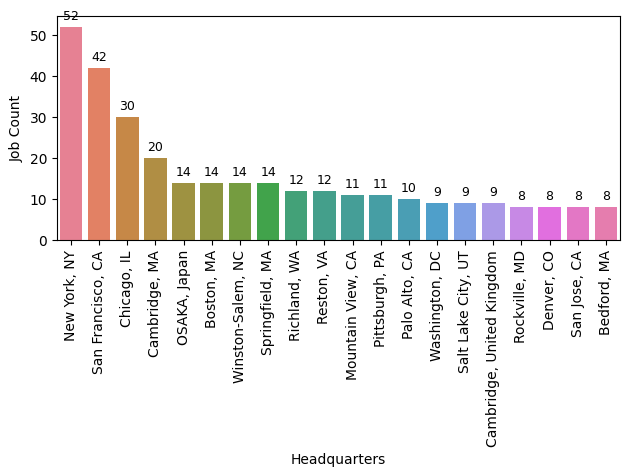

graph for company_txt: total = 20


/tmp/ipykernel_1056/1701252395.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart = sns.barplot(x=cat_num.index, y=cat_num, palette="husl")
/tmp/ipykernel_1056/1701252395.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


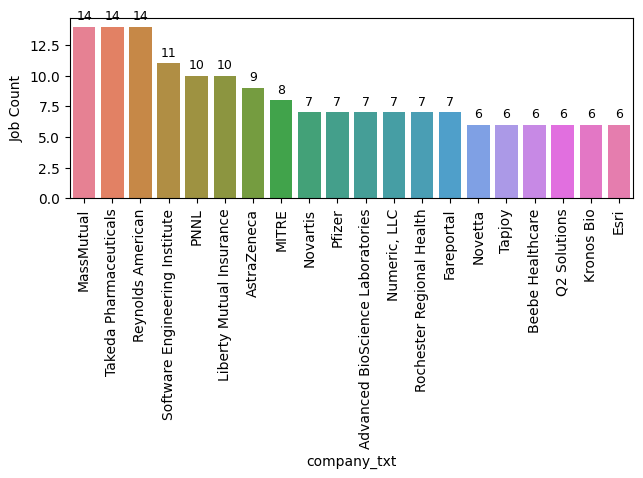

In [ ]:
for i in df_cat[['Location','Headquarters','company_txt']].columns:
    cat_num = df_cat[i].value_counts()[:20]
    print("graph for %s: total = %d" % (i, len(cat_num)))
    chart = sns.barplot(x=cat_num.index, y=cat_num, palette="husl")
    chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
    for p in chart.patches:
        chart.annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width()/2., p.get_height()),
            ha='center',
            va='bottom',
            fontsize=9,
            xytext=(0, 3),
            textcoords='offset points')
    plt.xlabel(i)
    plt.ylabel("Job Count")
    plt.tight_layout()
    plt.show()

**Pair Plot** : For Categorical features

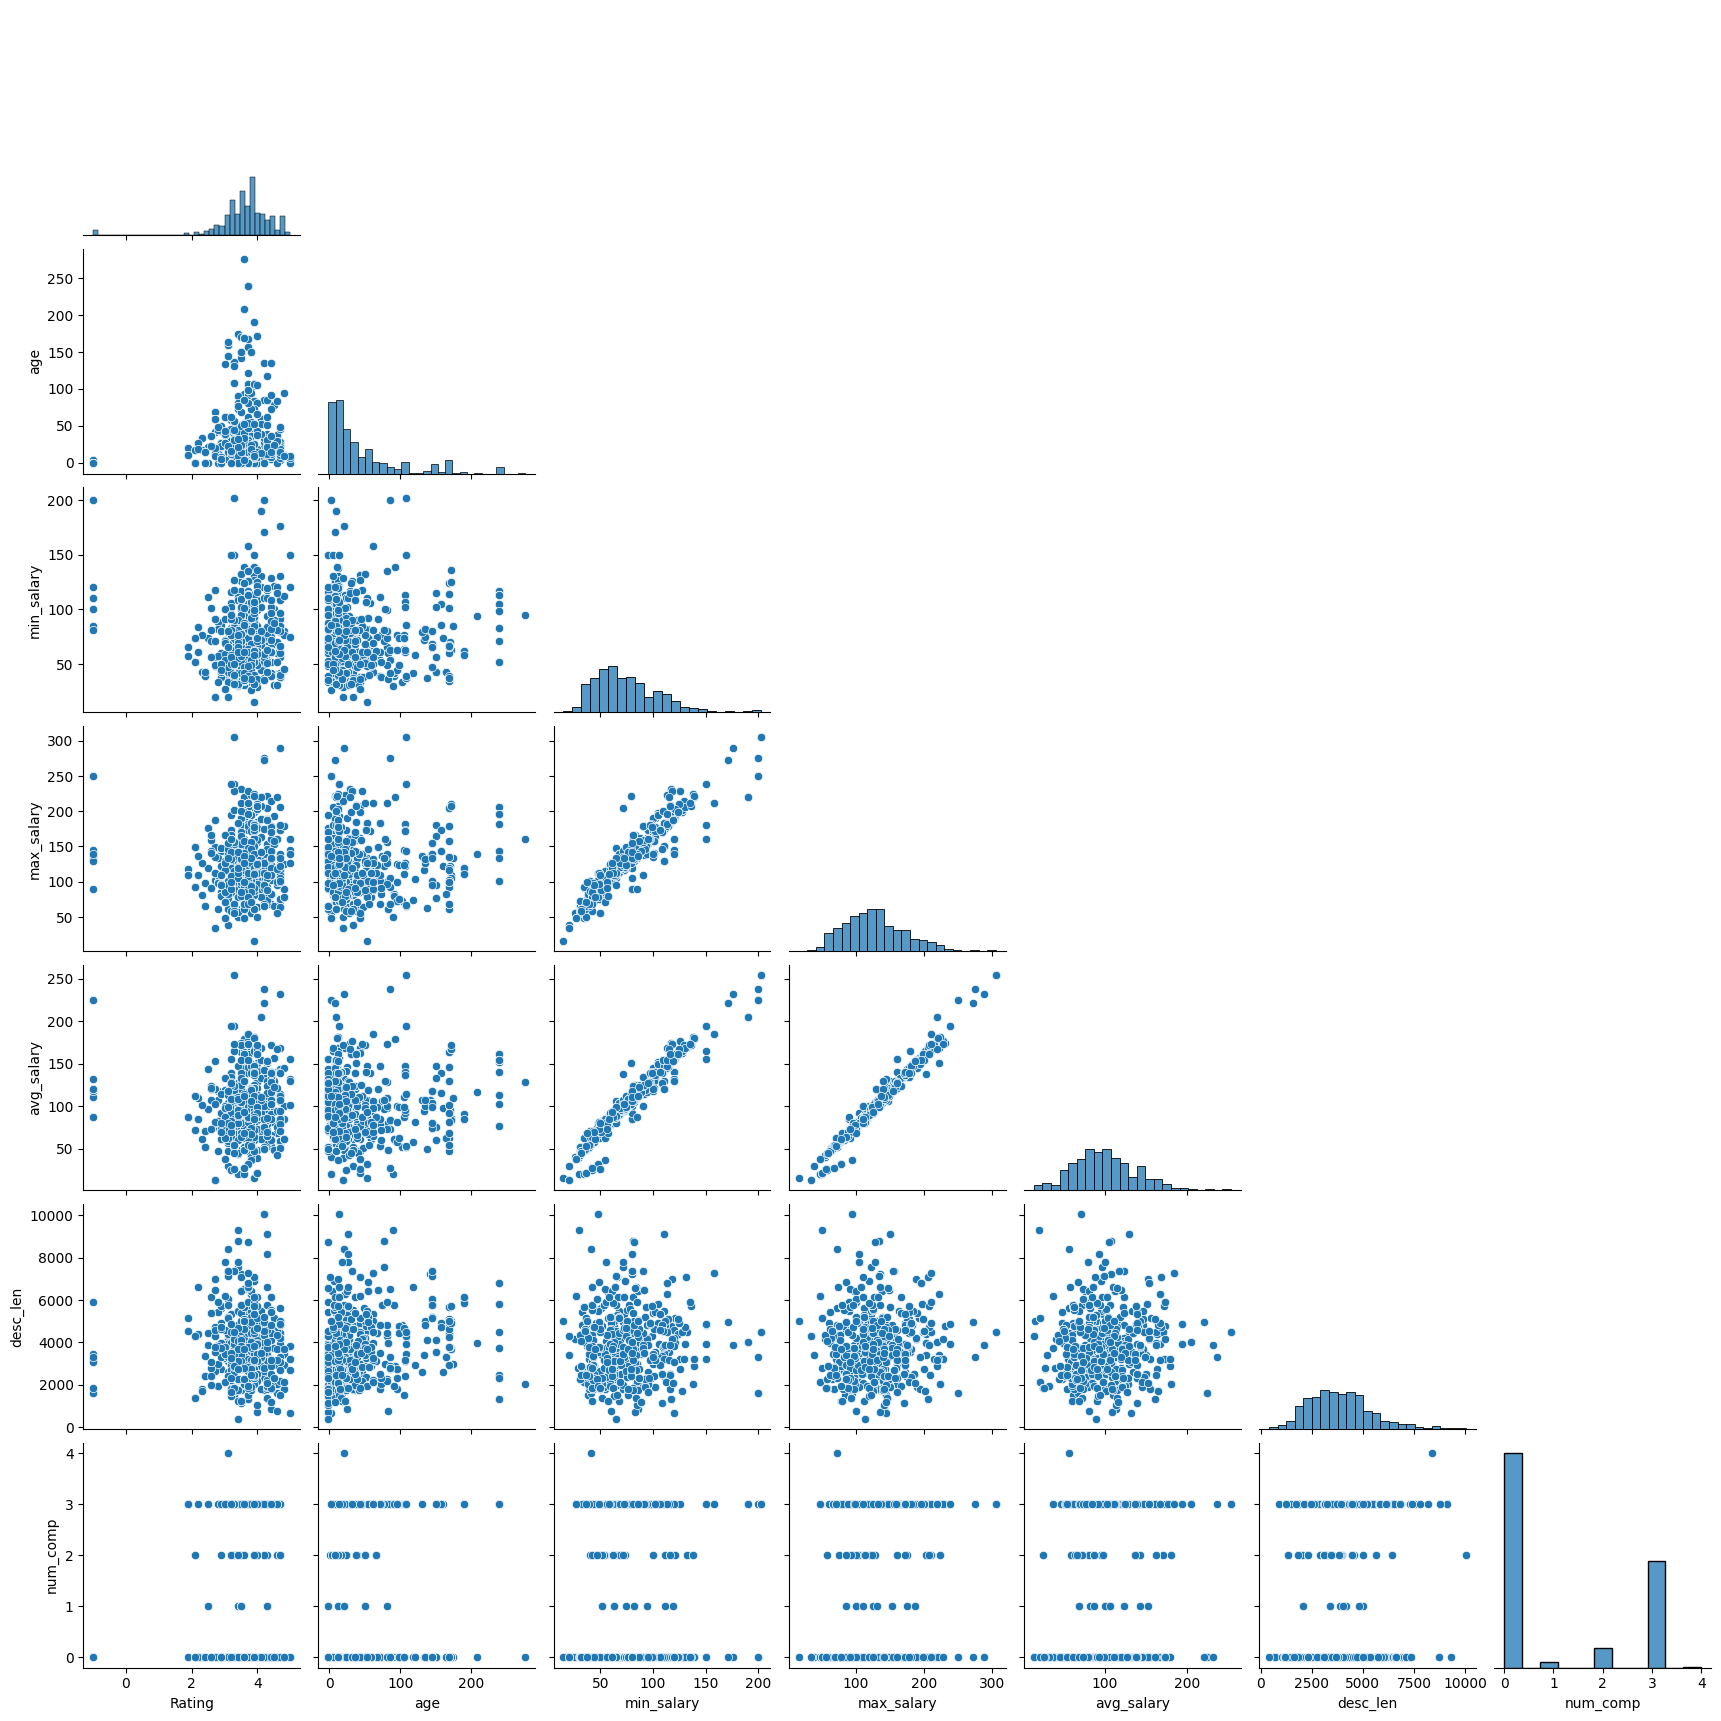

In [ ]:
num_cols = [
    'Rating',
    'age',
    'min_salary',
    'max_salary',
    'avg_salary',
    'desc_len',
    'num_comp'
]

sns.pairplot(
    df[num_cols],
    diag_kind='hist',      # Histogram on diagonal
    corner=True            # Show only lower triangle
)

plt.show()

**Pair Plot** : For binary features

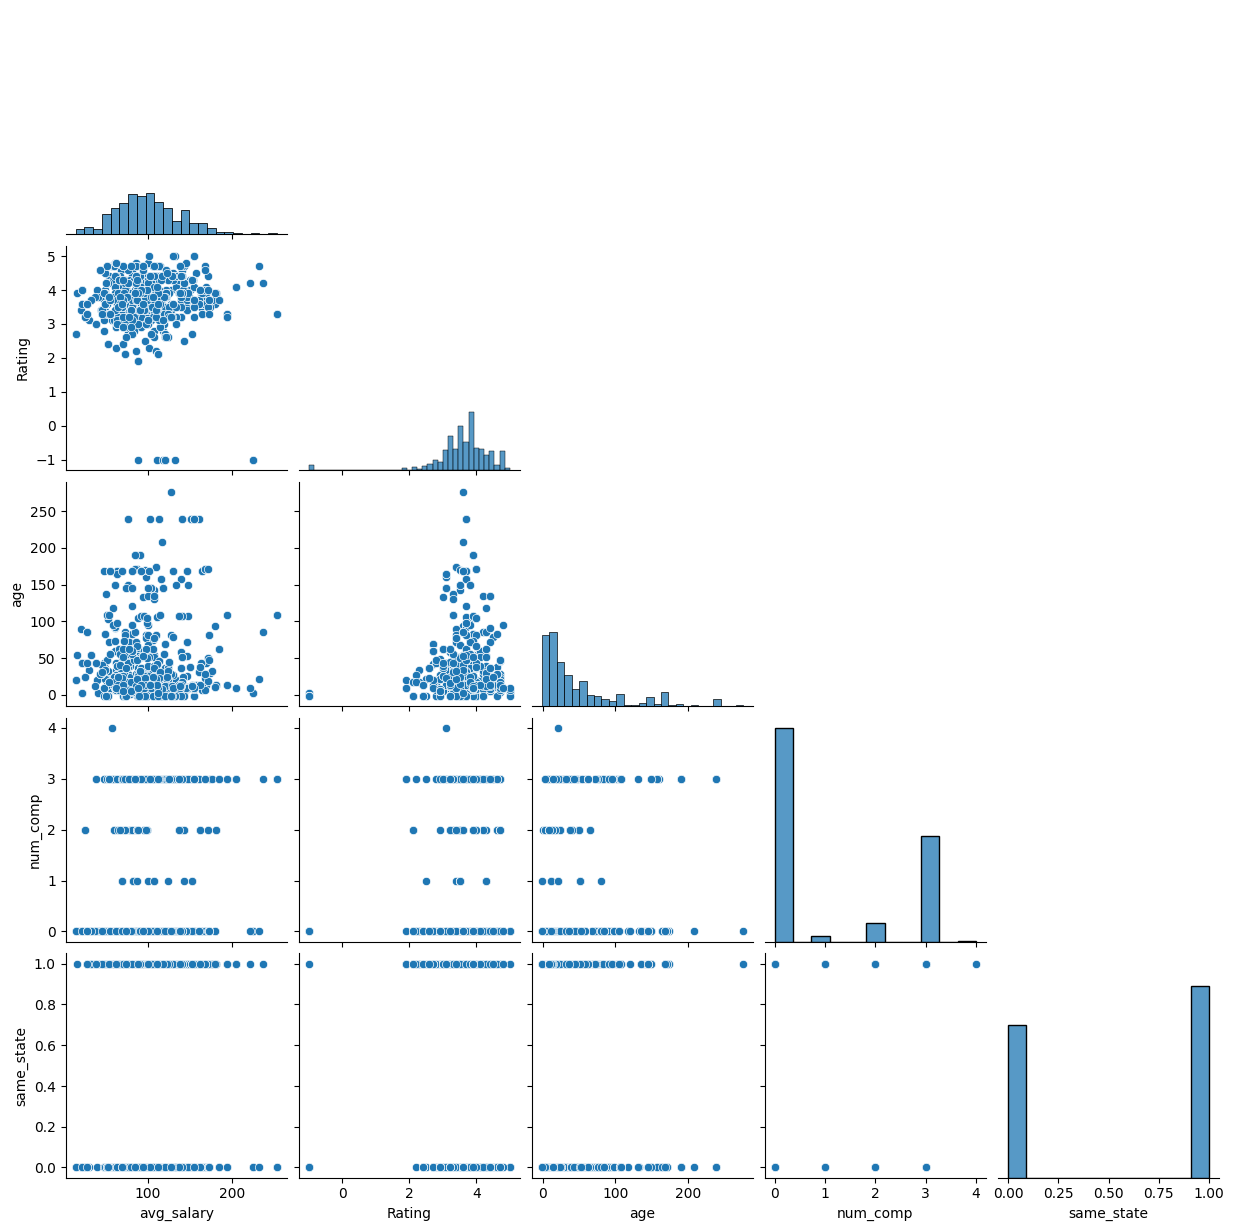

In [ ]:
num_cols2 = [
    'avg_salary',
    'Rating',
    'age',
    'num_comp',
    'same_state'
]

sns.pairplot(
    df[num_cols2],
    diag_kind='hist',
    corner=True
)

plt.show()

**Pair Plot**: for Salary analysis

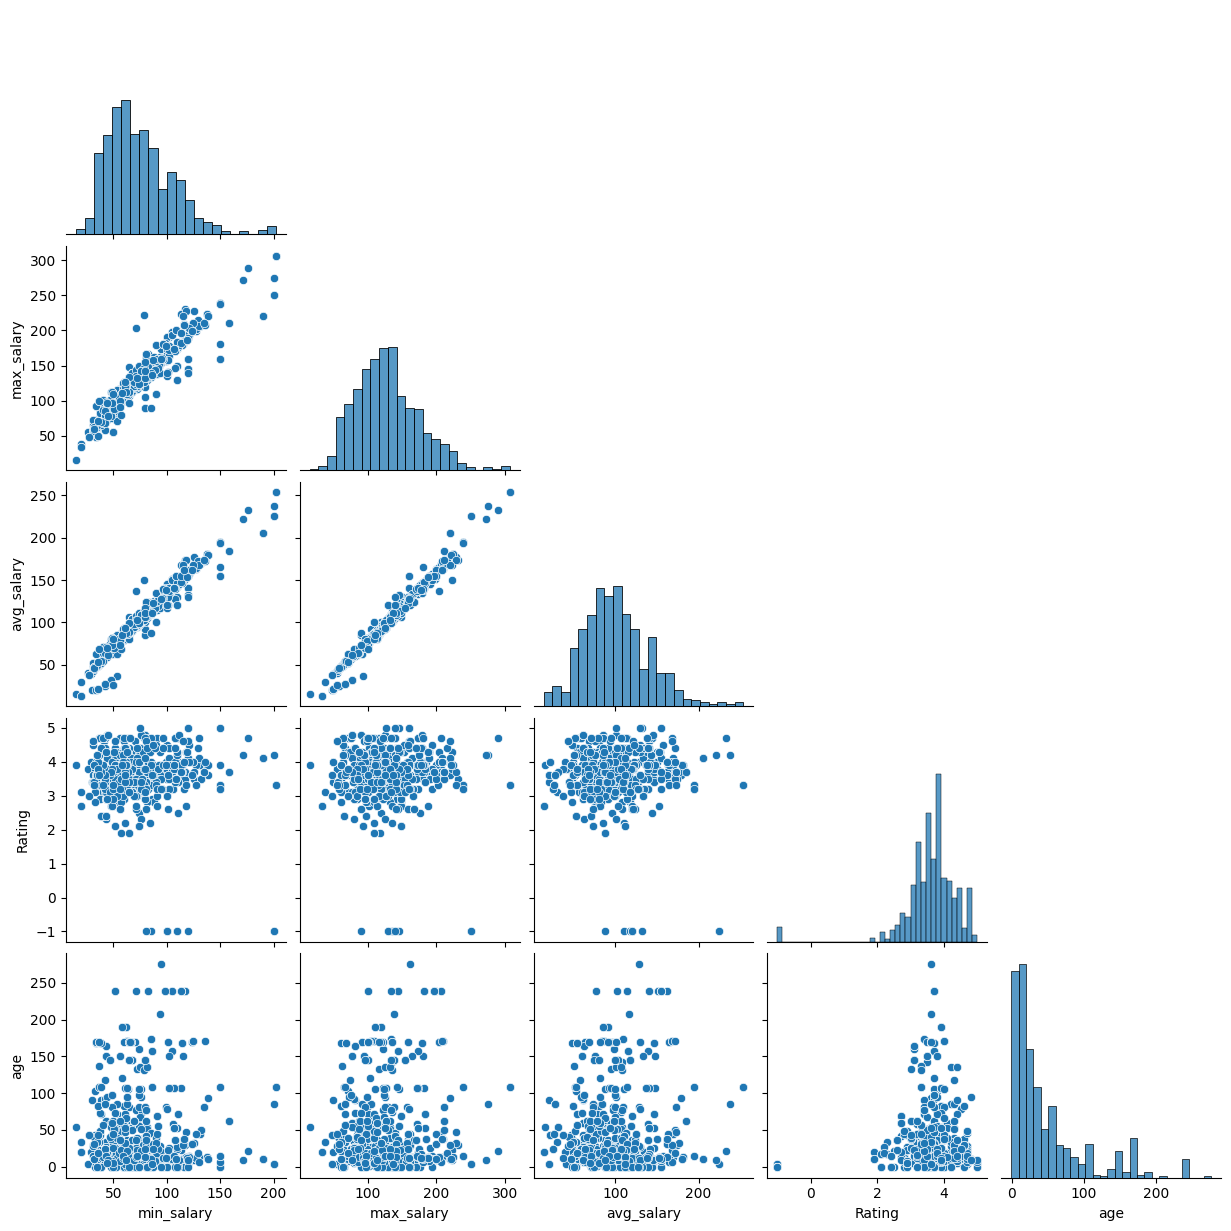

In [ ]:
sns.pairplot(
    df[['min_salary','max_salary','avg_salary','Rating','age']],
    diag_kind='hist',
    corner=True
)

plt.show()

**How does salary vary by job position (e.g., Data Scientist vs. Software Engineer vs. DevOps Engineer)?**

In [ ]:
pd.pivot_table(df, index = 'job', values = 'avg_salary')

,avg_salary
job,
analyst,65.857843
data engineer,105.403361
data scientist,117.564516
director,168.607143
manager,84.022727
mle,126.431818
na,84.853261


**How does salary vary by job Experaince? (e.g., Data Scientist vs. Software Engineer vs. DevOps Engineer)?**

In [ ]:
pd.pivot_table(df, index = ['job','seniority'], values = 'avg_salary')

avg_salary
job            seniority            
analyst        jr          56.500000
               na          61.155405
               senior      79.092593
data engineer  na          96.701220
               senior     124.689189
data scientist jr         106.500000
               na         107.043011
               senior     138.956522
director       na         168.607143
manager        na          84.022727
mle            na         119.133333
               senior     142.071429
na             na          73.988189
               senior     109.061404

**How do salaries differ by location (e.g., San Francisco vs. Austin vs. New York)?**

In [ ]:
pd.pivot_table(df, index = ['job_state','job'], values = 'avg_salary').sort_values('job_state', ascending = False)

avg_salary
job_state job                       
WI        na               54.000000
          data scientist  113.500000
          analyst          58.833333
WA        na               97.500000
          data scientist   99.764706
...                              ...
AZ        analyst          55.000000
          na              124.500000
AL        na               43.750000
          data engineer    65.000000
          analyst          62.200000

[114 rows x 1 columns]

In [ ]:
pd.options.display.max_rows
pd.set_option('display.max_rows', None)

**what is the count of Jobs per position by location?**

In [ ]:
pd.pivot_table(df, index = ['job_state','job'], values = 'avg_salary', aggfunc = 'count').sort_values('job_state', ascending = False)

avg_salary
job_state job                       
WI        na                       4
          data scientist           3
          analyst                  3
WA        na                       1
          data scientist          17
          analyst                  3
VA        na                       5
          mle                      2
          data scientist          18
          data engineer           10
          analyst                  6
UT        data engineer            3
          analyst                  4
          data scientist           3
TX        na                       7
          data scientist          13
          data engineer            8
TN        data scientist           1
          data engineer           10
          analyst                  2
SC        na                       1
RI        analyst                  1
PA        manager                  3
          data engineer            1
          data scientist           6
          analyst                  8
          mle                      7
          na                       8
OR        data scientist           3
          data engineer            1
OH        na                       3
          data scientist           7
          analyst                  4
NY        na                      12
          mle                      2
          data scientist          40
          data engineer            4
          analyst                 14
NM        data scientist           3
NJ        data scientist           4
          analyst                  6
          data engineer            2
          manager                  2
          director                 2
          na                       1
NE        na                       4
NC        na                      12
          data scientist           3
          data engineer            6
MO        na                       3
          manager                  1
          data scientist           3
          analyst                  2
MN        data engineer            1
          analyst                  1
MI        manager                  2
          data scientist           4
MD        na                      16
          data scientist          13
          data engineer            3
          analyst                  3
MA        na                      46
          manager                  5
          director                 6
          data scientist          30
          data engineer           12
          analyst                  4
LA        analyst                  1
          data engineer            2
          na                       1
KY        na                       4
          data scientist           2
KS        mle                      3
IN        na                       4
          data scientist           2
          data engineer            4
IL        analyst                  3
          na                       6
          mle                      2
          director                 6
          data scientist          15
          data engineer            8
ID        analyst                  2
IA        analyst                  2
          data engineer            3
GA        data scientist           3
          na                       3
FL        data scientist           7
          data engineer            3
          analyst                  6
DE        na                       6
DC        data scientist           5
          data engineer            4
          analyst                  2
CT        na                       3
          data scientist           2
CO        mle                      1
          data engineer            3
          analyst                  1
          na                       3
          data scientist           3
CA        na                      27
          mle                      5
          manager                  9
          data scientist          68
          data engineer           25
          analyst             

In [ ]:
pd.pivot_table(df[df.job == 'data scientist'], index = 'job_state', values = 'avg_salary').sort_values('avg_salary', ascending = False)

,avg_salary
job_state,
DC,149.000000
CA,142.522059
UT,140.500000
MO,127.666667
IL,117.233333
NC,117.000000
NY,115.250000
MA,113.750000
WI,113.500000


# **5. Model Fitting**

In [ ]:
#Data is split into training and testing data
df_model = df[['avg_salary','Rating','Size','Type of ownership','Industry','Sector','Revenue','num_comp','hourly','employer_provided',
             'job_state','same_state','age','python_yn','spark','aws','excel','seniority','desc_len']]
df_dum = pd.get_dummies(df_model)
df_dum.head()

,avg_salary,Rating,num_comp,hourly,employer_provided,same_state,age,python_yn,spark,aws,...,job_state_SC,job_state_TN,job_state_TX,job_state_UT,job_state_VA,job_state_WA,job_state_WI,seniority_jr,seniority_na,seniority_senior
0,72.0,3.8,0,0,0,0,47,1,0,0,...,False,False,False,False,False,False,False,False,True,False
1,87.5,3.4,0,0,0,0,36,1,0,0,...,False,False,False,False,False,False,False,False,True,False
2,85.0,4.8,0,0,0,1,10,1,1,0,...,False,False,False,False,False,False,False,False,True,False
3,76.5,3.8,3,0,0,1,55,1,0,0,...,False,False,False,False,False,True,False,False,True,False
4,114.5,2.9,3,0,0,1,22,1,0,0,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
#Create data set for training model
from sklearn.model_selection import train_test_split

X = df_dum.drop('avg_salary', axis =1)
y = df_dum.avg_salary.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((593, 170), (149, 170), (593,), (149,))

**cross_val_score()** is a function from Scikit-learn that evaluates the performance of a machine learning model using Cross Validation (CV).

Instead of testing the model on just one train-test split, it tests the model multiple times on different splits of the data and returns the score for each split.

To builds a linear regression model, evaluates its statistical significance using OLS, and measures its prediction performance using 3-fold cross-validation with Mean Absolute Error (MAE).

In [ ]:
# Build Linear regresion model
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Convert all columns to float
X = X.astype(float)

# Convert y to float
y = np.asarray(y).astype(float)

# Add intercept
X_sm = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X_sm)
results = model.fit()

print(results.summary())

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import cross_val_score

lm = LinearRegression()
lm.fit(X_train, y_train)

np.mean(cross_val_score(lm,X_train,y_train, scoring = 'neg_mean_absolute_error', cv= 3))   #CV = number of folds

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import cross_val_score

lm = LinearRegression()
lm.fit(X_train, y_train)

np.mean(cross_val_score(lm,X_train,y_train, scoring = 'neg_mean_absolute_error', cv= 3))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.601
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     6.708
Date:                Wed, 05 Aug 2026   Prob (F-statistic):           1.47e-61
Time:                        13:02:32   Log-Likelihood:                -3426.8
No. Observations:                 742   AIC:                             7128.
Df Residuals:                     605   BIC:                             7759.
Df Model:                         136                                         
Covariance Type:            nonrobust                                         
                                                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

np.float64(-23.90662327606171)

**MAE of Liner regression model is 23.09. It indicate that model is moderate**

**R sqaure of model is 0.601 thus this model is moderate fit to data This means the independent variables explain 60.1% of the variation in the dependent variable (y). The remaining 39.9% of the variation is due to other factors not included in the model.**

**F-statistic = 6.708**
**Prob(F-statistic) = 1.47 * 10⁻⁶¹, which is much smaller than 0.05, we reject the null hypothesis that all regression coefficients are zero..**

**Conclusion: The model is statistically significant, indicating that the predictors, taken together, have a significant relationship with the dependent variable.**

**R² = 0.601**
**Adjusted R² = 0.512**
**Number of predictors (Df Model) = 136**

**The gap between R² and Adjusted R² suggests some predictors may not be useful.**

p-value < 0.05 → Significant contributor
p-value ≥ 0.05 → Non-contributor (not statistically significant)

**Predictors like 'Same state', 'age', 'spak', 'Desc len' are non useful for model.**

To finds the optimal Lasso regularization parameter (alpha) by evaluating different alpha values using 3-fold cross-validation and selecting the one with the lowest Mean Absolute Error (MAE).

,alpha,error
9,0.1,-21.990803


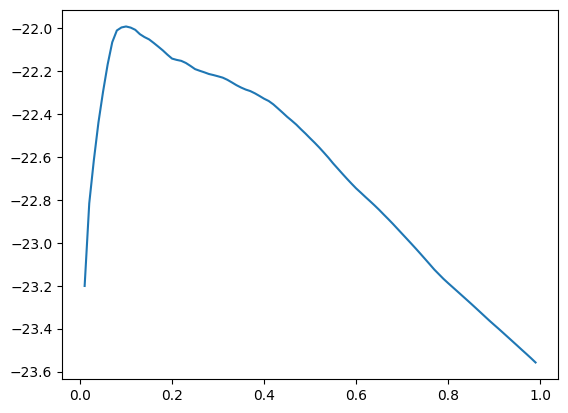

In [ ]:
lm_l = Lasso(alpha=.13)
lm_l.fit(X_train,y_train)
np.mean(cross_val_score(lm_l,X_train,y_train, scoring = 'neg_mean_absolute_error', cv= 3))

alpha = []
error = []

for i in range(1,100):
    alpha.append(i/100)
    lml = Lasso(alpha=(i/100))
    error.append(np.mean(cross_val_score(lml,X_train,y_train, scoring = 'neg_mean_absolute_error', cv= 3)))

plt.plot(alpha,error)

err = tuple(zip(alpha,error))
df_err = pd.DataFrame(err, columns = ['alpha','error'])
df_err[df_err.error == max(df_err.error)]

**The optimal alpha among the tested values (0.01 to 0.99) is 0.1**

**Lesso model performs best when alpha is 0.1 because cross validation score is highest i.e -21.99 this actul mean absolute error is 21.99**

**MAE is 21.99 It indiate that this model is moderate.**

**Also it mean On average, the model's salary prediction differs from the actual salary by approximately 21.99 salary units**

To creates a Random Forest Regression model and evaluates its average prediction error using 3-fold cross-validation with Mean Absolute Error (MAE).

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()

np.mean(cross_val_score(rf,X_train,y_train,scoring = 'neg_mean_absolute_error', cv= 3))

np.float64(-17.45575971218103)

**Random Forest Regression returns the negative of the Mean Absolute Error (MAE). Thus MAE = 17.46**

On average, your Random Forest model's predictions differ from the actual values by about 17.46 units. If your target variable (avg_salary) is measured in thousands of dollars, then:

The predicted salary is off by approximately $17,460 on average.

**Random Forest has the lowest MAE (17.46) among these models,**

**Therefore, Random Forest predicts salaries more accurately than both Linear Regression and Lasso Regression on your dataset.**

To performs hyperparameter tuning on a Random Forest Regressor using GridSearchCV to find the parameter combination that minimizes the Mean Absolute Error (MAE) through 3-fold cross-validation.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

parameters = {
    'n_estimators': range(10, 301, 10),
    'criterion': ['squared_error', 'absolute_error'],
    'max_features': ['sqrt', 'log2']
}

gs = GridSearchCV(
    estimator=rf,
    param_grid=parameters,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1
)

gs.fit(X_train, y_train)

print("Best Score:", gs.best_score_)
print("Best Parameters:", gs.best_params_)
print("Best Estimator:", gs.best_estimator_)

Best Score: -17.23949404863639
Best Parameters: {'criterion': 'squared_error', 'max_features': 'sqrt', 'n_estimators': 240}
Best Estimator: RandomForestRegressor(max_features='sqrt', n_estimators=240, random_state=42)


**Compared with the default Random Forest model, hyperparameter tuning slightly improved prediction accuracy (MAE reduced from about 17.46 unit to 17.24 unnit) i.e 17230 Dollers. This suggests that the default model was already performing well, and tuning provided a modest but measurable improvement.**